# Actividad MongoDB

Instalar:

```bash
pip install pymongo
```


In [1]:
import json

# Datos que vamos a guardar en JSON
datos_empresa = {
  "empresa": "TechSolutions Inc.",
  "fundacion": 2010,
  "activo": True,
  "direccion": {
    "calle": "Av. Tecnológica 123",
    "ciudad": "Silicon Valley",
    "pais": "Estados Unidos"
  },
  "departamentos": [
    {
      "nombre": "Desarrollo",
      "empleados": 25,
      "tecnologias": ["Python", "JavaScript", "SQL"]
    },
    {
      "nombre": "Marketing",
      "empleados": 10,
      "tecnologias": ["Google Analytics", "SEO"]
    },
    {
      "nombre": "Ventas",
      "empleados": 15,
      "tecnologias": ["CRM", "Excel"]
    }
  ],
  "proyectos_destacados": [
    {
      "nombre": "Sistema de Gestión",
      "cliente": "Acme Corp",
      "presupuesto": 50000
    },
    {
      "nombre": "App Móvil",
      "cliente": "StartUp X",
      "presupuesto": 75000
    }
  ]
}

# Guardar los datos en un archivo JSON
with open('datos.json', 'w', encoding='utf-8') as f:
    json.dump(datos_empresa, f, ensure_ascii=False, indent=2)

print("Archivo 'datos.json' creado exitosamente!")

Archivo 'datos.json' creado exitosamente!


### Conexión a la base de datos y consulta

In [ ]:
from pymongo import MongoClient
import pandas as pd
from IPython.display import display

# Establecer conexión con MongoDB generalmente con un try para buenas prácticas
try:
    # Conexión a MongoDB (sin autenticación)
    client = MongoClient('mongodb://localhost:27017/')
    db = client['empresas'] # Colocar aquí tu base de datos
    coleccion = db['empresas'] # Coolocar aquí tu colección
    
    # Consulta equivalente a SELECT * en MySQL
    # find() sin parámetros devuelve todos los documentos
    documentos = coleccion.find()
    
    # Convertir los documentos a DataFrame de pandas
    df = pd.DataFrame(list(documentos))
    
    # MongoDB añade automáticamente un campo '_id', podemos eliminarlo si no lo necesitamos
    #if '_id' in df.columns:
     #   df.drop('_id', axis=1,inplace=True)
    
    # Mostrar el DataFrame
    print("Datos de la colección 'empresas':")
    display(df)
    
    # Mostrar información básica de la colección
    print("\nInformación de la colección:")
    print(f"Total de documentos: {coleccion.count_documents({})}")
    print(f"Primeros campos: {list(df.columns)}")

except Exception as e:
    print(f"Error al conectar con MongoDB: {e}")

finally:
    # Cerrar la conexión
    if 'client' in locals():
        client.close()
        print("\nConexión a MongoDB cerrada")

Datos de la colección 'empresas':


,empresa,fundacion,activo,direccion,departamentos,proyectos_destacados
0,TechSolutions Inc.,2010,True,"{'calle': 'Av. Tecnológica 123', 'ciudad': 'Si...","[{'nombre': 'Desarrollo', 'empleados': 25, 'te...","[{'nombre': 'Sistema de Gestión', 'cliente': '..."



Información de la colección:
Total de documentos: 1
Primeros campos: ['empresa', 'fundacion', 'activo', 'direccion', 'departamentos', 'proyectos_destacados']

Conexión a MongoDB cerrada


Visualizar el json

In [15]:
from pymongo import MongoClient
import pandas as pd
from IPython.display import display, JSON

# 1. Conectar a MongoDB y obtener datos
client = MongoClient('mongodb://localhost:27017/')
db = client['empresas'] # Colocar aquí tu base de datos
coleccion = db['empresas'] # Coolocar aquí tu colección
datos = coleccion.find_one()
client.close()

# 2. Visualización básica
print("\n=== Visualización básica del JSON ===")
print(f"Empresa: {datos['empresa']}")
print(f"Año de fundación: {datos['fundacion']}")
print(f"Dirección: {datos['direccion']['calle']}")


# 3. Convertir a DataFrame de Pandas (para datos tabulares)
print("\n=== Departamentos (DataFrame) ===")
df_departamentos = pd.DataFrame(datos['departamentos'])
display(df_departamentos)

print("\n=== Proyectos destacados (DataFrame) ===")
df_proyectos = pd.DataFrame(datos['proyectos_destacados'])
display(df_proyectos)




=== Visualización básica del JSON ===
Empresa: TechSolutions Inc.
Año de fundación: 2010
Dirección: Av. Tecnológica 123

=== Departamentos (DataFrame) ===


,nombre,empleados,tecnologias
0,Desarrollo,25,"[Python, JavaScript, SQL]"
1,Marketing,10,"[Google Analytics, SEO]"
2,Ventas,15,"[CRM, Excel]"



=== Proyectos destacados (DataFrame) ===


,nombre,cliente,presupuesto
0,Sistema de Gestión,Acme Corp,50000
1,App Móvil,StartUp X,75000


Visualización con gráficos

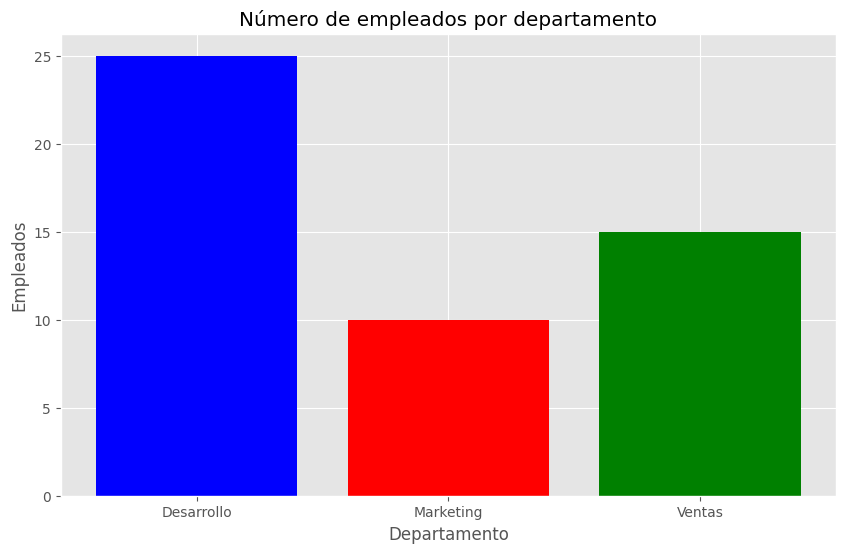

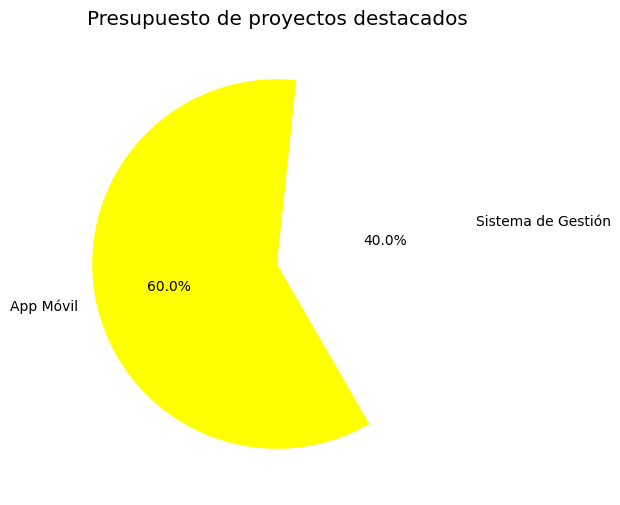

In [25]:
import matplotlib.pyplot as plt

# Configurar estilo
plt.style.use('ggplot')
df_departamentos = pd.DataFrame(datos['departamentos'])
df_proyectos = pd.DataFrame(datos['proyectos_destacados'])

# Gráfico de empleados por departamento
plt.figure(figsize=(10, 6))
plt.bar(df_departamentos['nombre'], df_departamentos['empleados'],color=['blue', 'red', 'green'])
plt.title('Número de empleados por departamento')
plt.xlabel('Departamento')
plt.ylabel('Empleados')
plt.show()

# Gráfico de presupuesto de proyectos
plt.figure(figsize=(10, 6))
plt.pie(df_proyectos['presupuesto'], labels=df_proyectos['nombre'], colors=['white', 'yellow'],startangle=-60,autopct='%1.1f%%')
plt.title('Presupuesto de proyectos destacados')
plt.show()
